# GR

* [GR LP filter + Interpolation (Pre-Processing)](#Low-Pass-Filter)
* [GR vs TVT](#GR-vs-TVT)
* [GR in MD domain from TW](#TW-in-MD)
* [GR in Z domain from TW](#TW-in-Z)
* GR Normalization: Not figured out yet

In [1]:
import os
import glob
import numpy as np
np.random.seed(42)
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Automatically detect if running on Kaggle or Locally
IS_KAGGLE = os.path.exists('/kaggle/input')
BASE_DIR = '/kaggle/input/competitions/rogii-wellbore-geology-prediction' if IS_KAGGLE else '../data'

print(f"Running on {'Kaggle' if IS_KAGGLE else 'Local Environment'}")
print(f"Data Directory: {BASE_DIR}")
train_data = os.path.join(BASE_DIR, "train")
file_paths = sorted(os.listdir(train_data))
file_paths[:4]

Running on Local Environment
Data Directory: ../data


['.DS_Store',
 '000d7d20.png',
 '000d7d20__horizontal_well.csv',
 '000d7d20__typewell.csv']

In [3]:
# Regex pattern: 
pattern = re.compile(r'([^/\\]+)__horizontal_well\.csv')

well_names = []
for path in file_paths:
    match = pattern.search(path)
    if match:
        well_names.append(match.group(1))

print("Extracted Well Names:")
print(len(well_names), "Well Names")

Extracted Well Names:
773 Well Names


In [4]:
well = np.random.choice(well_names)
# well = 'd24ff243' # A lengthy well

hw = pd.read_csv(train_data + f"/{well}__horizontal_well.csv")
tw = pd.read_csv(train_data + f"/{well}__typewell.csv")
pic = train_data + f"/{well}.png"

mask = hw['TVT_input'].isna()
evalz = hw[mask].copy()
known = hw[~mask].copy()

well, hw.shape, tw.shape, evalz.shape

(np.str_('23b9beb0'), (8790, 13), (1422, 3), (7340, 13))

## Low-Pass-Filter

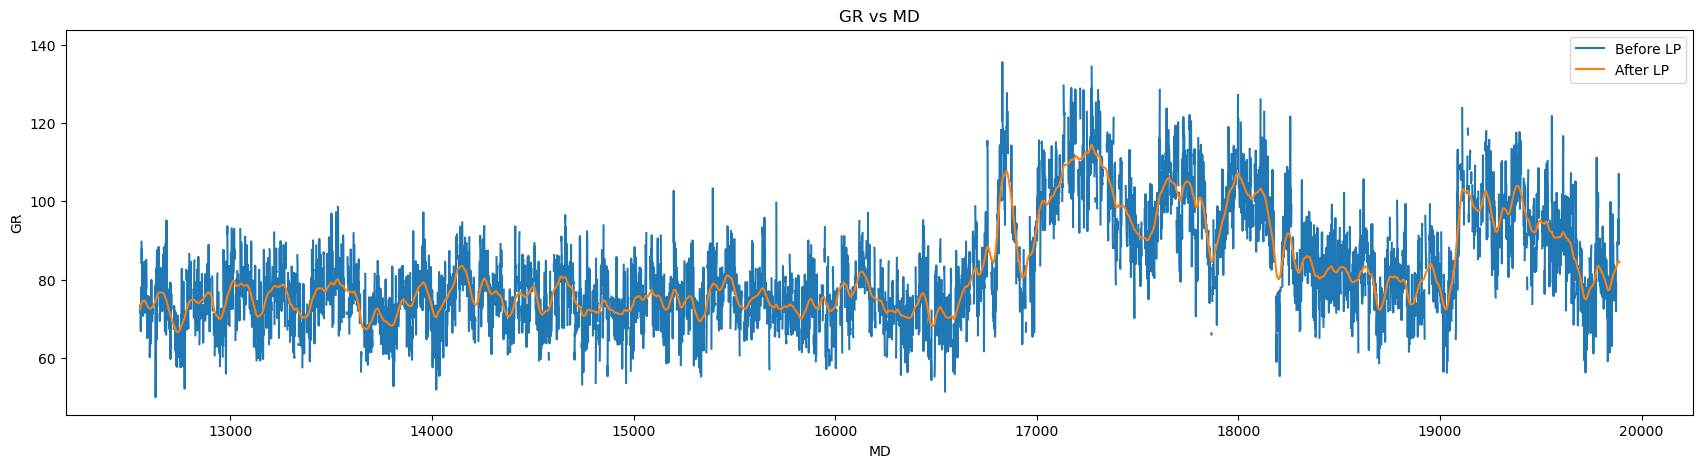

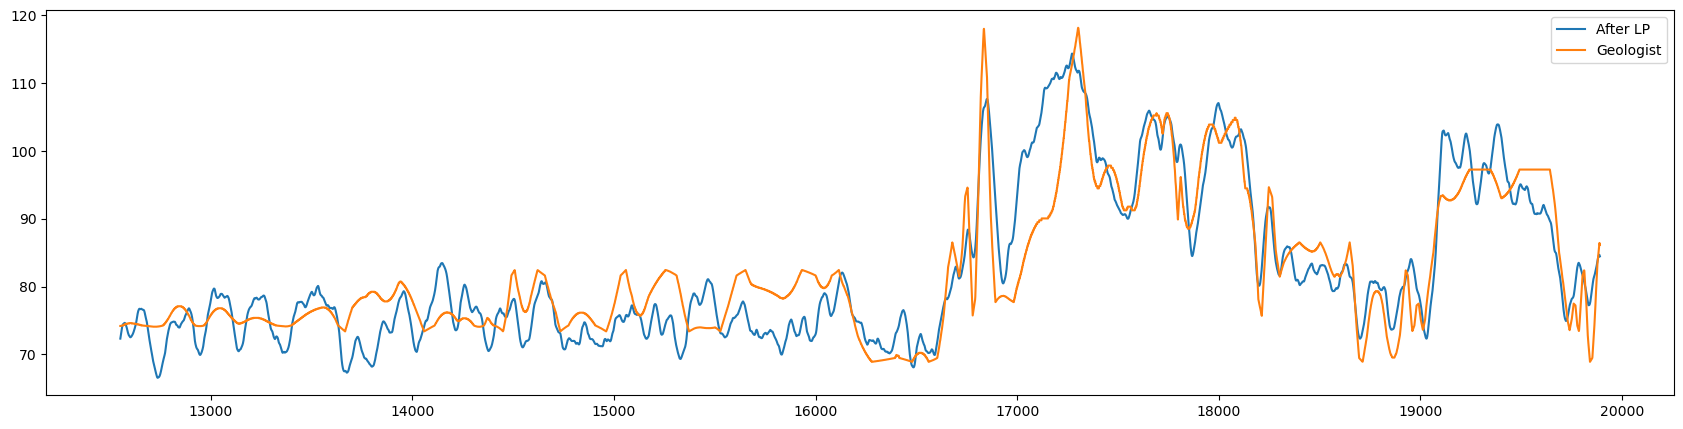

In [5]:
from scipy.signal import butter, filtfilt
from scipy.stats import pearsonr

HW_LOW_PASS_CUTOFF = 0.009
def remove_rotation_noise(gr_series, cutoff=HW_LOW_PASS_CUTOFF):
    """Low pass filter."""
    gr_filled = gr_series.interpolate(method='linear').bfill().ffill()
    nyquist = 0.5 
    normal_cutoff = cutoff / nyquist
    b, a = butter(1, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, gr_filled)

plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['GR'], label='Before LP')

evalz['orig_GR'] = evalz['GR']
evalz['GR'] = remove_rotation_noise(evalz['GR'])

plt.plot(evalz['MD'], evalz['GR'], label='After LP')
plt.title('GR vs MD')
plt.xlabel('MD')
plt.ylabel('GR')
plt.legend()

plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['GR'], label='After LP')
plt.plot(evalz['MD'], np.interp(evalz['TVT'], tw['TVT'], tw['GR']), label='Geologist')
plt.legend()

In [6]:
from ipywidgets import interact
import ipywidgets as widgets
def plot_interactive_lp(cutoff):
    plt.figure(figsize=(21, 5))
    
    # Plot original data
    # plt.plot(evalz['MD'], evalz['orig_GR'], label='Before LP', alpha=0.5)
    plt.plot(evalz['MD'], np.interp(evalz['TVT'], tw['TVT'], tw['GR']), label='Geologist')
        
    # Apply filter with the active slider value
    filtered_gr = remove_rotation_noise(evalz['orig_GR'], cutoff=cutoff)
    
    # Plot filtered data
    plt.plot(evalz['MD'], filtered_gr, label=f'After LP (Cutoff: {cutoff:.4f})', color='orange')
    
    plt.title('GR vs MD')
    plt.xlabel('MD')
    plt.ylabel('GR')
    plt.legend()
    plt.show() # Required inside widgets to refresh the plot cleanly

# Create the interactive slider
interact(
    plot_interactive_lp, 
    cutoff=widgets.FloatSlider(
        value=HW_LOW_PASS_CUTOFF, 
        min=0.001, 
        max=0.09, 
        step=0.001, 
        description='Cutoff:',
        readout_format='.3f'
    )
)

interactive(children=(FloatSlider(value=0.009, description='Cutoff:', max=0.09, min=0.001, readout_format='.3f…

<function __main__.plot_interactive_lp(cutoff)>

## GR-vs-TVT

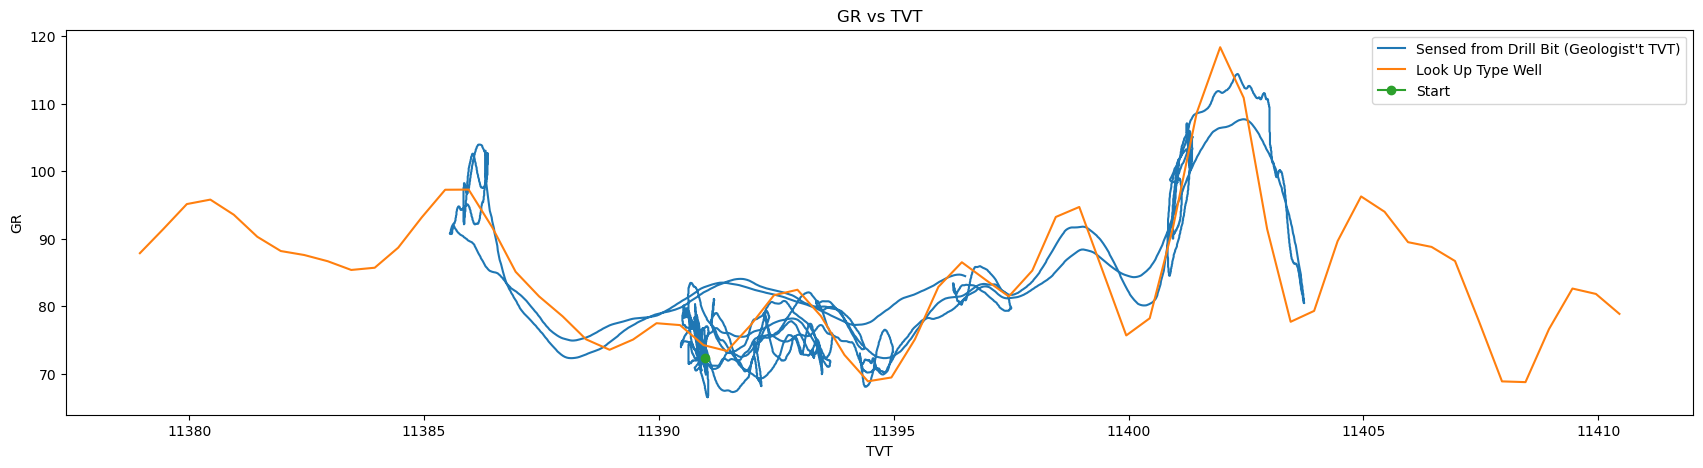

In [7]:
plt.figure(figsize=(21, 5))

plt.plot(evalz['TVT'], evalz['GR'], label="Sensed from Drill Bit (Geologist't TVT)")
mx, mn = evalz['TVT'].max(), evalz['TVT'].min()
tw_evalz = tw[(tw['TVT'] < mx + 7) & (tw['TVT'] > mn - 7)]
plt.plot(tw_evalz['TVT'], tw_evalz['GR'], label='Look Up Type Well')

plt.plot(evalz['TVT'].iloc[0], evalz['GR'].iloc[0], label='Start', marker='o')
plt.title('GR vs TVT')
plt.ylabel('GR')
plt.xlabel('TVT')
plt.legend()

## TW-in-MD

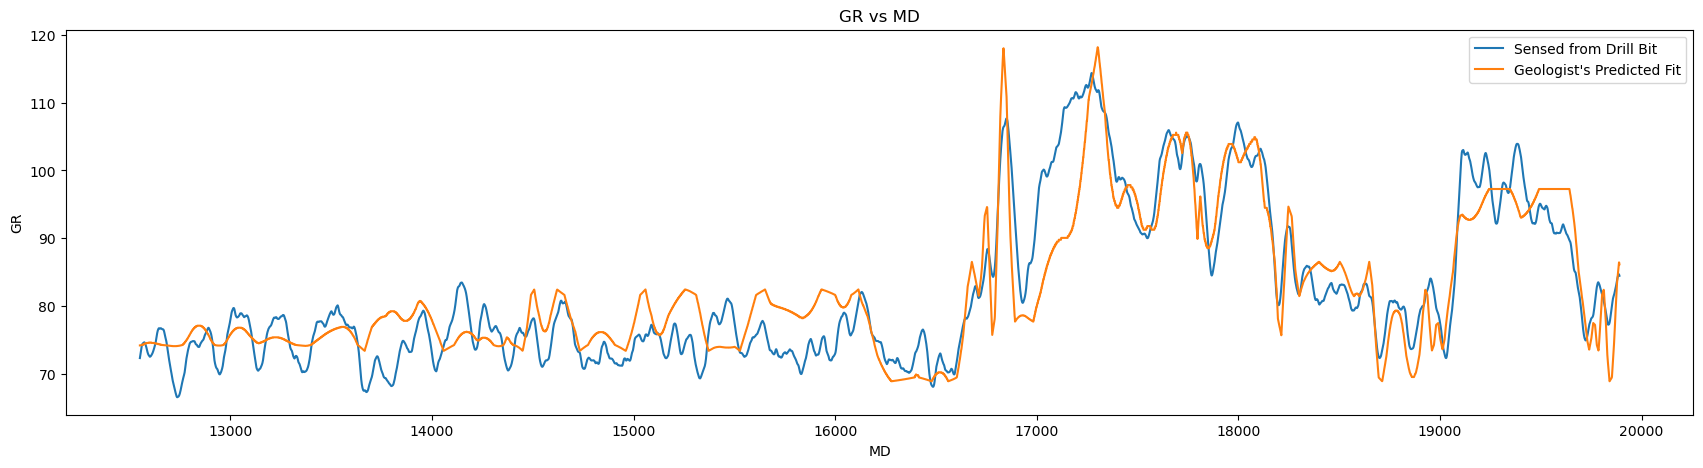

In [8]:
plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['GR'], label='Sensed from Drill Bit')

pred_tvt = evalz['TVT'] # Placeholder

pred_gr = np.interp(pred_tvt, tw['TVT'], tw['GR'])
plt.plot(evalz['MD'], pred_gr, label="Geologist's Predicted Fit")
plt.title('GR vs MD')
plt.ylabel('GR')
plt.xlabel('MD')
plt.legend()

## TW-in-Z

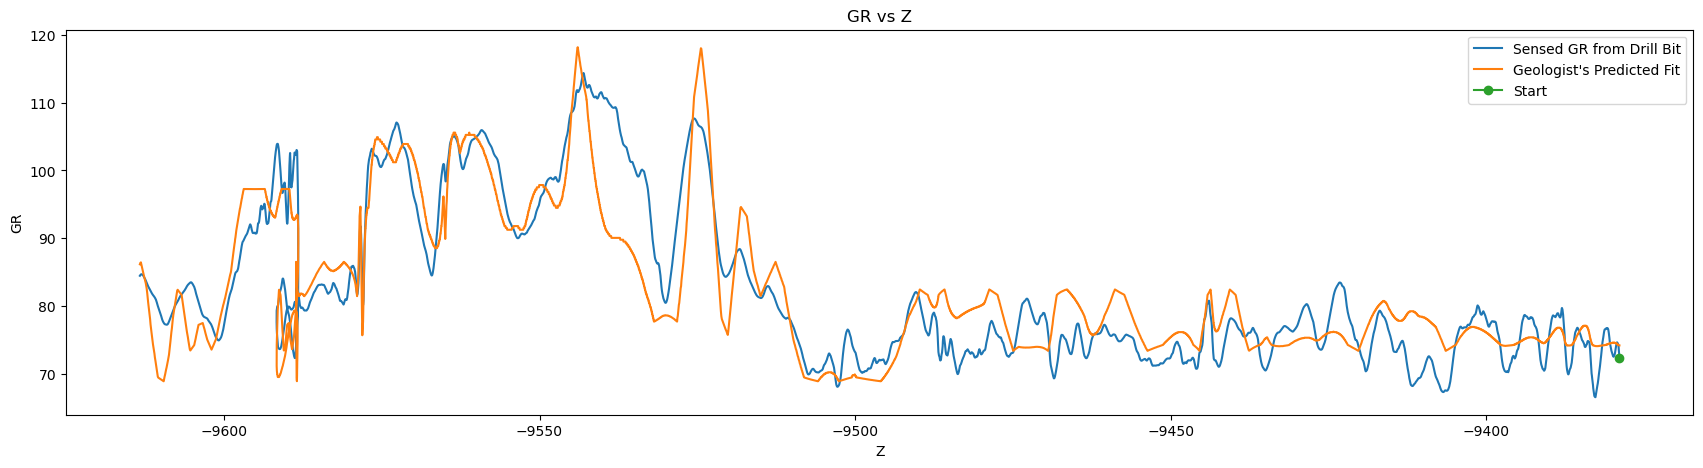

In [9]:
axes = ['Z']
for axis in axes:
    plt.figure(figsize=(21, 5))
    plt.plot(evalz[axis], evalz['GR'], label='Sensed GR from Drill Bit')
    
    pred_tvt = evalz['TVT'] # Placeholder
    
    pred_gr = np.interp(pred_tvt, tw['TVT'], tw['GR'])
    plt.title(f'GR vs {axis}')
    plt.plot(evalz[axis], pred_gr, label="Geologist's Predicted Fit")
    plt.plot(evalz[axis].iloc[0], evalz['GR'].iloc[0], label='Start', marker='o')
    plt.ylabel('GR')
    plt.xlabel(axis)
    plt.legend()

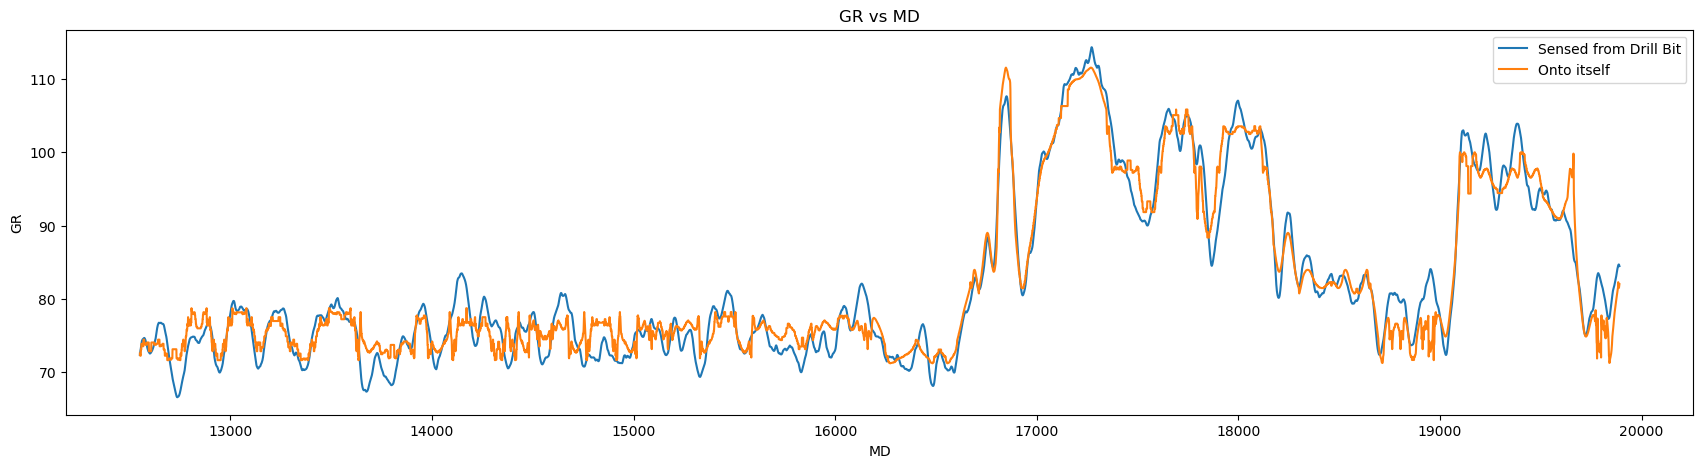

In [10]:
plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['GR'], label='Sensed from Drill Bit')

pred_tvt = evalz['TVT'] # Placeholder

e = known.sort_values(by="TVT")
e = evalz.sort_values(by="TVT")
e['GR'] = remove_rotation_noise(e['GR'])

pred_gr = np.interp(pred_tvt, e['TVT'], e['GR'])
plt.plot(evalz['MD'], pred_gr, label="Onto itself")
plt.title('GR vs MD')
plt.ylabel('GR')
plt.xlabel('MD')
plt.legend()

## Measuring Geologist's Match

In [11]:
# RMSE (API)
np.sqrt(np.mean((pred_gr - evalz['GR'])**2))

np.float64(2.7948952857713842)

In [12]:
# Correlation
from scipy.stats import pearsonr, spearmanr
pearsonr(evalz['GR'], pred_gr), spearmanr(evalz['GR'], pred_gr)

(PearsonRResult(statistic=np.float64(0.9693659817272763), pvalue=np.float64(0.0)),
 SignificanceResult(statistic=np.float64(0.89027865848892), pvalue=np.float64(0.0)))

In [13]:
# MAE
np.mean(np.abs(pred_gr - evalz['GR']))

np.float64(2.127471904388244)

In [14]:
# Earth Mover's Distance
actual_gr = evalz['GR']

actual_norm = actual_gr / np.sum(actual_gr)
pred_norm = pred_gr / np.sum(pred_gr)

actual_cumsum = np.cumsum(actual_norm)
pred_cumsum = np.cumsum(pred_norm)

# Calculate the Distance (This continuously DECREASES to 0 as shapes align)
emd_distance = np.sum(np.abs(actual_cumsum - pred_cumsum))

emd_distance

np.float64(11.888832320050971)

## Calibration: Not done yet
* We need to develop a normalization and a measure such that:
    * The measure rewards the correct way, significantly more than wrong ways
        * Need to find wrong ways
    * The measure continously increases in reward only with doing the right predictions

In [15]:
well = np.random.choice(well_names)
well = '2b06ad65'

hw = pd.read_csv(train_data + f"/{well}__horizontal_well.csv")
tw = pd.read_csv(train_data + f"/{well}__typewell.csv")

mask = hw['TVT_input'].isna()
evalz = hw[mask].copy()

evalz['GR'] = remove_rotation_noise(evalz['GR'].copy())

## Matching evalz['GR'] vs tw['GR'] vs known['GR']

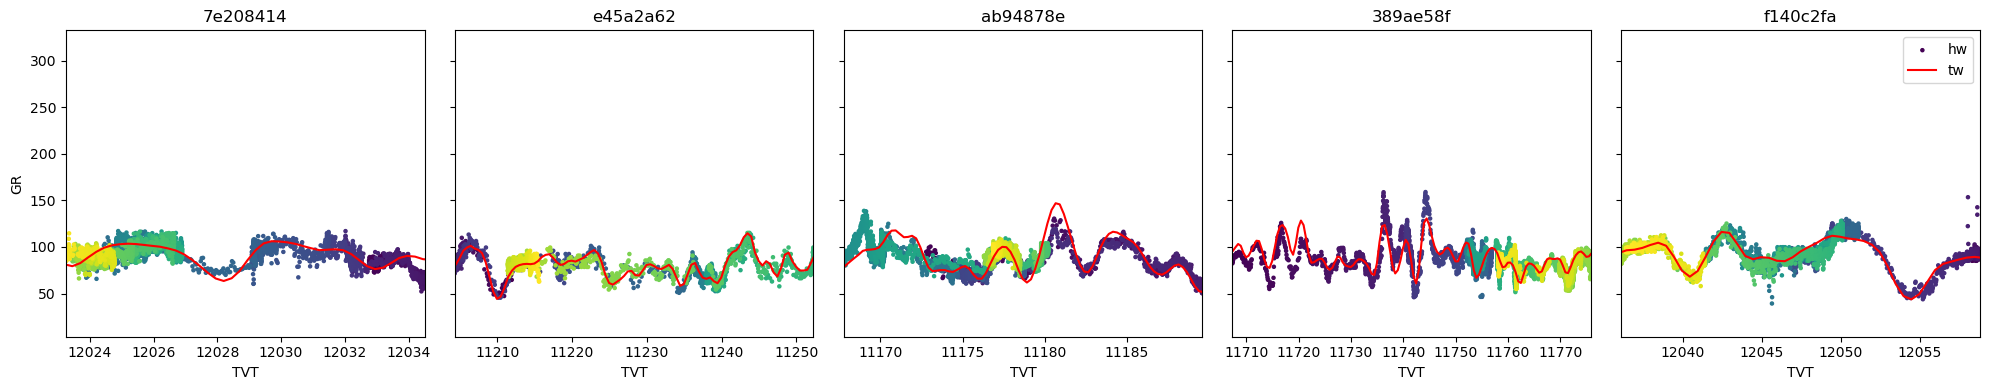

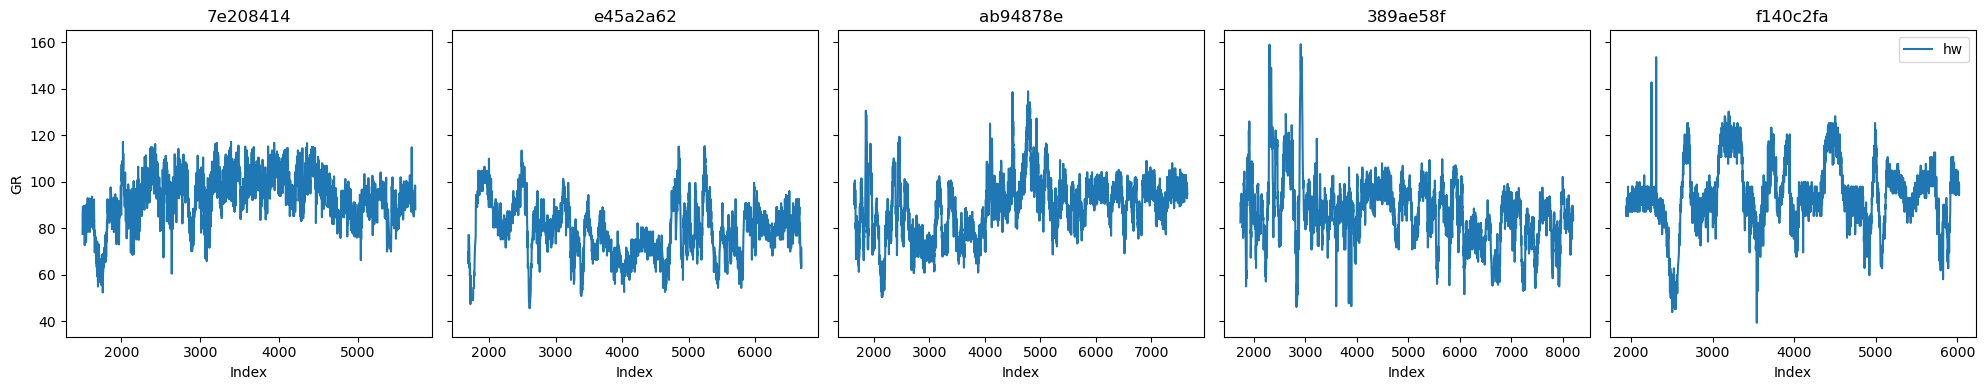

In [16]:
np.random.seed(42)

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
sample_wells = np.random.choice(well_names, size=5, replace=False)
for name, ax in zip(sample_wells, axes):
    hw = pd.read_csv(f"{train_data}/{name}__horizontal_well.csv")
    tw = pd.read_csv(f"{train_data}/{name}__typewell.csv")
    mask = hw['TVT_input'].isna()
    scatter = ax.scatter(hw['TVT'][mask], hw['GR'][mask], 
                         c=hw.index[mask], cmap='viridis', 
                         s=5, label='hw')
    ax.plot(tw['TVT'], tw['GR'], label='tw', color='red')
    ax.set_title(name)
    ax.set_xlabel('TVT')
    ax.set_xlim(hw['TVT'][mask].min(), hw['TVT'][mask].max())
axes[0].set_ylabel('GR')
plt.legend()
plt.tight_layout()
plt.show()

fill = lambda df: df.interpolate(method='linear', limit_direction='both')

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for name, ax in zip(sample_wells, axes):
    hw = pd.read_csv(f"{train_data}/{name}__horizontal_well.csv")
    tw = pd.read_csv(f"{train_data}/{name}__typewell.csv")
    mask = hw['TVT_input'].isna()
    ax.plot(fill(hw['GR'][mask]), label='hw')
    ax.set_title(name)
    ax.set_xlabel('Index')
axes[0].set_ylabel('GR')
plt.legend()
plt.tight_layout()
plt.show()